In [ ]:
!pip install -q xarray netcdf4 h5netcdf dask matplotlib seaborn scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.9 MB/s eta 0:00:00


In [ ]:
import os
import glob
import zipfile
import shutil
import json
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

if tf.config.list_physical_devices("GPU"):
    print("GPU is available.")
else:
    print("WARNING: TensorFlow GPU is NOT available.")

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available.


In [ ]:
!nvidia-smi

Sat Sep 26 09:30:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q xarray netCDF4 h5netcdf dask[complete] tqdm matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.4 MB/s eta 0:00:00


In [ ]:
import os
import glob
import zipfile
import calendar
import json
import random
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

from sklearn.metrics import mean_squared_error

In [ ]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
from google.colab import drive

# 1. Drive mount karo
drive.mount('/content/drive')

# 2. Search roots
search_roots = [
    Path("/content/drive/MyDrive"),
    Path("/content")
]

zip_files = []

for root in search_roots:
    if root.exists():
        zip_files.extend(root.rglob("Bay_of_Bengal_*.zip"))

# duplicates remove
zip_files = sorted(set(zip_files))

print("Total ZIP files found:", len(zip_files))
for z in zip_files:
    print(z)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total ZIP files found: 24
/content/drive/MyDrive/Bay of bengal data/Bay_of_Bengal_2024-01.zip
/content/drive/MyDrive/Bay of bengal data/Bay_of_Bengal_2024-02.zip
/content/drive/MyDrive/Bay of bengal data/Bay_of_Bengal_2024-03.zip
/content/drive/MyDrive/Bay of bengal data/Bay_of_Bengal_2024-04.zip
/content/drive/MyDrive/Bay of bengal data/Bay_of_Bengal_2024-05.zip
/content/drive/MyDrive/Bay of bengal data/Bay_of_Bengal_2024-06.zip
/content/drive/MyDrive/Bay of bengal data/Bay_of_Bengal_2024-07.zip
/content/drive/MyDrive/Bay of bengal data/Bay_of_Bengal_2024-08.zip
/content/drive/MyDrive/Bay of bengal data/Bay_of_Bengal_2024-09.zip
/content/drive/MyDrive/Bay of bengal data/Bay_of_Bengal_2024-10.zip
/content/drive/MyDrive/Bay of bengal data/Bay_of_Bengal_2024-11.zip
/content/drive/MyDrive/Bay of bengal data/Bay_of_Bengal_2024-12.zip
/content/drive/MyDrive/Bay of

In [ ]:
months = []

for z in zip_files:
    month = z.stem.replace("Bay_of_Bengal_", "")
    months.append(month)

months = sorted(months)

print("Months found:")
for m in months:
    print(m)

print("\nTotal months:", len(months))

Months found:
2024-01
2024-02
2024-03
2024-04
2024-05
2024-06
2024-07
2024-08
2024-09
2024-10
2024-11
2024-12
2025-01
2025-02
2025-03
2025-04
2025-05
2025-06
2025-07
2025-08
2025-09
2025-10
2025-11
2025-12

Total months: 24


In [ ]:
for zip_path in zip_files:

    month_label = zip_path.stem.replace("Bay_of_Bengal_", "")

    year, month = map(int, month_label.split("-"))

    expected_days = calendar.monthrange(year, month)[1]

    with zipfile.ZipFile(zip_path, "r") as z:
        nc_files = [
            name for name in z.namelist()
            if name.endswith(".nc")
        ]

    actual_days = len(nc_files)

    status = "✅" if actual_days == expected_days else "⚠️"

    print(
        f"{status} {month_label} | "
        f"Expected: {expected_days} | "
        f"Found: {actual_days}"
    )

✅ 2024-01 | Expected: 31 | Found: 31
✅ 2024-02 | Expected: 29 | Found: 29
✅ 2024-03 | Expected: 31 | Found: 31
✅ 2024-04 | Expected: 30 | Found: 30
✅ 2024-05 | Expected: 31 | Found: 31
✅ 2024-06 | Expected: 30 | Found: 30
✅ 2024-07 | Expected: 31 | Found: 31
✅ 2024-08 | Expected: 31 | Found: 31
✅ 2024-09 | Expected: 30 | Found: 30
✅ 2024-10 | Expected: 31 | Found: 31
✅ 2024-11 | Expected: 30 | Found: 30
✅ 2024-12 | Expected: 31 | Found: 31
✅ 2025-01 | Expected: 31 | Found: 31
✅ 2025-02 | Expected: 28 | Found: 28
✅ 2025-03 | Expected: 31 | Found: 31
✅ 2025-04 | Expected: 30 | Found: 30
✅ 2025-05 | Expected: 31 | Found: 31
✅ 2025-06 | Expected: 30 | Found: 30
✅ 2025-07 | Expected: 31 | Found: 31
✅ 2025-08 | Expected: 31 | Found: 31
✅ 2025-09 | Expected: 30 | Found: 30
✅ 2025-10 | Expected: 31 | Found: 31
⚠️ 2025-11 | Expected: 30 | Found: 29
✅ 2025-12 | Expected: 31 | Found: 31


In [ ]:
total_nc = 0

for zip_path in zip_files:
    with zipfile.ZipFile(zip_path, "r") as z:
        total_nc += sum(
            1 for name in z.namelist()
            if name.endswith(".nc")
        )

print("Total daily NetCDF files:", total_nc)
print("Expected:", 731)

if total_nc == 731:
    print("✅ Complete 2-year dataset")
else:
    print("⚠️ Some daily files are missing")

Total daily NetCDF files: 730
Expected: 731
⚠️ Some daily files are missing


In [ ]:
ML_ROOT = Path("/content/OceanEmbed")

DAILY_ROOT = ML_ROOT / "Daily"

DAILY_ROOT.mkdir(parents=True, exist_ok=True)

print(ML_ROOT)

/content/OceanEmbed


In [ ]:
for zip_path in tqdm(zip_files, desc="Extracting ZIPs"):

    month_label = zip_path.stem.replace("Bay_of_Bengal_", "")

    month_dir = DAILY_ROOT / month_label
    month_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(month_dir)

print("✅ Extraction complete")

Extracting ZIPs:   0%|          | 0/24 [00:00<?, ?it/s]

✅ Extraction complete


In [ ]:
daily_files = sorted(DAILY_ROOT.rglob("combined_bay_of_bengal-*.nc"))

print("Total extracted NetCDF files:", len(daily_files))

Total extracted NetCDF files: 730


In [ ]:
# checking the file structure
sample_file = daily_files[0]

print("Sample file:")
print(sample_file)

ds = xr.open_dataset(sample_file)

print(ds)

Sample file:
/content/OceanEmbed/Daily/2024-01/combined_bay_of_bengal-20240101.nc
<xarray.Dataset> Size: 4MB
Dimensions:           (time: 1, y: 68, x: 80, depth: 15)
Coordinates:
  * time              (time) datetime64[ns] 8B 2024-01-01
  * depth             (depth) float32 60B 0.0 5.0 10.0 ... 500.0 700.0 1e+03
    lon               (y, x) float64 44kB ...
    lat               (y, x) float64 44kB ...
Dimensions without coordinates: y, x
Data variables: (12/37)
    analysed_sst      (time, y, x) float64 44kB ...
    analysis_error    (time, y, x) float64 44kB ...
    mask              (time, y, x) float32 22kB ...
    sea_ice_fraction  (time, y, x) float64 44kB ...
    dos               (time, y, x) float64 44kB ...
    dos_error         (time, y, x) float64 44kB ...
    ...                ...
    thetao            (time, depth, y, x) float64 653kB ...
    uo                (time, depth, y, x) float64 653kB ...
    usi               (time, y, x) float64 44kB ...
    vo                

In [ ]:
# checking variables
print("Variables:")
for var in ds.data_vars:
    print(
        f"{var:20s}",
        ds[var].dims,
        ds[var].shape
    )

Variables:
analysed_sst         ('time', 'y', 'x') (1, 68, 80)
analysis_error       ('time', 'y', 'x') (1, 68, 80)
mask                 ('time', 'y', 'x') (1, 68, 80)
sea_ice_fraction     ('time', 'y', 'x') (1, 68, 80)
dos                  ('time', 'y', 'x') (1, 68, 80)
dos_error            ('time', 'y', 'x') (1, 68, 80)
sos                  ('time', 'y', 'x') (1, 68, 80)
sos_error            ('time', 'y', 'x') (1, 68, 80)
adt                  ('time', 'y', 'x') (1, 68, 80)
err_sla              ('time', 'y', 'x') (1, 68, 80)
err_ugosa            ('time', 'y', 'x') (1, 68, 80)
err_vgosa            ('time', 'y', 'x') (1, 68, 80)
flag_ice             ('time', 'y', 'x') (1, 68, 80)
sla                  ('time', 'y', 'x') (1, 68, 80)
ugos                 ('time', 'y', 'x') (1, 68, 80)
ugosa                ('time', 'y', 'x') (1, 68, 80)
vgos                 ('time', 'y', 'x') (1, 68, 80)
vgosa                ('time', 'y', 'x') (1, 68, 80)
u                    ('time', 'y', 'x') (1, 68, 80)
v

In [ ]:
print("Dimensions:")
print(ds.dims)

print("\nCoordinates:")
for coord in ds.coords:
    print(coord, ds[coord].shape)

Dimensions:
FrozenMappingWarningOnValuesAccess({'time': 1, 'y': 68, 'x': 80, 'depth': 15})

Coordinates:
time (1,)
lon (68, 80)
lat (68, 80)
depth (15,)


In [ ]:
if "depth" in ds.coords:
    print("Depths:")
    print(ds["depth"].values)
elif "depth" in ds.dims:
    print("Depths:")
    print(ds["depth"].values)
else:
    print("⚠️ No depth coordinate found")

Depths:
[   0.    5.   10.   20.   30.   50.   75.  100.  125.  150.  200.  300.
  500.  700. 1000.]


In [ ]:
print("Dataset size:")
print(ds.nbytes / (1024**2), "MB")

Dataset size:
3.8391761779785156 MB


In [ ]:
# NAN analysis
for var in ds.data_vars:

    da = ds[var]

    total = da.size
    nan_count = np.isnan(da.values).sum()

    nan_percent = (nan_count / total) * 100

    print(
        f"{var:20s} "
        f"NaN: {nan_count:,} "
        f"({nan_percent:.2f}%)"
    )

analysed_sst         NaN: 1,390 (25.55%)
analysis_error       NaN: 1,390 (25.55%)
mask                 NaN: 0 (0.00%)
sea_ice_fraction     NaN: 1,388 (25.51%)
dos                  NaN: 1,445 (26.56%)
dos_error            NaN: 0 (0.00%)
sos                  NaN: 1,445 (26.56%)
sos_error            NaN: 0 (0.00%)
adt                  NaN: 1,317 (24.21%)
err_sla              NaN: 1,416 (26.03%)
err_ugosa            NaN: 1,416 (26.03%)
err_vgosa            NaN: 1,416 (26.03%)
flag_ice             NaN: 1,317 (24.21%)
sla                  NaN: 1,317 (24.21%)
ugos                 NaN: 1,317 (24.21%)
ugosa                NaN: 1,317 (24.21%)
vgos                 NaN: 1,317 (24.21%)
vgosa                NaN: 1,317 (24.21%)
u                    NaN: 1,638 (30.11%)
v                    NaN: 1,638 (30.11%)
ug                   NaN: 1,536 (28.24%)
vg                   NaN: 1,536 (28.24%)
uwnd                 NaN: 0 (0.00%)
vwnd                 NaN: 0 (0.00%)
ws                   NaN: 0 (0.00%)
nobs 

In [ ]:
# EDA of SST
plt.figure(figsize=(10, 6))

if "SST" in ds:
    da = ds["SST"]
    print(da.dims)
    print(da.shape)

<Figure size 1000x600 with 0 Axes>

In [ ]:
'''
ML ka actual mathematical setup:
Hamare paas har day ke liye:
X = [
    SST,
    SSS,
    SSH,
    current_U,
    current_V,
    wind_U,
    wind_V
]
7 channels
(H, W, 7)
Bay of Bengal grid:
Longitude: 80°E → 100°E
Latitude : 5°N → 22°N
Resolution = 0.25°

so the model......

             OceanEmbed CNN
                   │
                   ↓
Input
69 × 81 × 7
                   │
                   ↓
       CNN / U-Net / Attention
                   │
                   ↓
Output
69 × 81 × 15
                   │
        ┌──────────┼──────────┐
        ↓          ↓          ↓
       0m         5m       ...1000m

Hum initial experiment ke liye:
TRAIN
Jan 2024 – Dec 2024
      ↓
366 days

VALIDATION
Jan 2025 – Jun 2025
      ↓
181 days

TEST
Jul 2025 – Dec 2025
      ↓
184 days

'''

In [ ]:
TRAIN_START = "2024-01-01"
TRAIN_END   = "2024-12-31"

VAL_START   = "2025-01-01"
VAL_END     = "2025-06-30"

TEST_START  = "2025-07-01"
TEST_END    = "2025-12-31"

print("Train:", TRAIN_START, "→", TRAIN_END)
print("Validation:", VAL_START, "→", VAL_END)
print("Test:", TEST_START, "→", TEST_END)

Train: 2024-01-01 → 2024-12-31
Validation: 2025-01-01 → 2025-06-30
Test: 2025-07-01 → 2025-12-31


In [ ]:
#Ab tak hum basically data acquisition → preprocessing → ML-ready raw dataset verification phase complete kar chuke hain.


Ab tak hum basically data acquisition → preprocessing → ML-ready raw dataset verification phase complete kar chuke hain.

Hamare paas: 24 monthly ZIPs
             2024-01 → 2025-12
we have total 731 files we are able to fetch only 730 files so we are going to go with that

Structure: OceanEmbed/
           └── Daily/
               ├── 2024-01/
               ├── 2024-02/
               ├── ...
               ├── 2025-11/
               └── 2025-12/

Actual file: 2024-01-01
Structure:

       Dimensions:
       time  = 1
       y     = 68
       x     = 80
       depth = 15

Coordinates:

lat = (68, 80)
lon = (68, 80)
depth = 15 depths are exactly correct   

We have NetCDF me 37 variables hain, but ML ke liye hume 7 input channels + 1 target variable chahiye.
| Physical variable | Actual NetCDF variable |
| ----------------- | ---------------------- |
| SST               | `analysed_sst`         |
| SSS               | `sos`                  |
| SSH/SLA           | `sla`                  |
| Current U         | `u`                    |
| Current V         | `v`                    |
| Wind U            | `uwnd`                 |
| Wind V            | `vwnd`                 |

X =
[
 analysed_sst,
 sos,
 sla,
 u,
 v,
 uwnd,
 vwnd
]


##Target Y

GLORYS temperature:
   Shape:

(time, depth, y, x)
=
(1, 15, 68, 80)
So model ka task:

7 surface variables
        ↓
      Model
        ↓
15 depth temperatures

In [ ]:
'''
SST       ≈ 25.55% NaN
SSS       ≈ 26.56% NaN
SSH       ≈ 24.21% NaN
Current   ≈ 30.11% NaN
Wind      = 0% NaN
'''

'\nSST       ≈ 25.55% NaN\nSSS       ≈ 26.56% NaN\nSSH       ≈ 24.21% NaN\nCurrent   ≈ 30.11% NaN\nWind      = 0% NaN\n'

In [ ]:
# Missing date identify
import zipfile
from datetime import datetime, timedelta

target_month = "2025-11"

zip_path = next(
    z for z in zip_files
    if z.stem == f"Bay_of_Bengal_{target_month}"
)

with zipfile.ZipFile(zip_path, "r") as z:
    nc_names = sorted([
        name for name in z.namelist()
        if name.endswith(".nc")
    ])

found_dates = set()

for name in nc_names:
    filename = Path(name).name

    # combined_bay_of_bengal-20251101.nc
    date_str = filename.replace(
        "combined_bay_of_bengal-", ""
    ).replace(".nc", "")

    found_dates.add(
        datetime.strptime(date_str, "%Y%m%d").date()
    )

year = 2025
month = 11

expected_dates = {
    datetime(year, month, day).date()
    for day in range(1, calendar.monthrange(year, month)[1] + 1)
}

missing_dates = sorted(expected_dates - found_dates)

print("Missing dates:")
for d in missing_dates:
    print(d)

print("\nNumber missing:", len(missing_dates))

Missing dates:
2025-11-05

Number missing: 1


In [ ]:
# Actual variable ranges check
input_vars = [
    "analysed_sst",
    "sos",
    "sla",
    "u",
    "v",
    "uwnd",
    "vwnd"
]

target_var = "thetao"

print("INPUT VARIABLES")
print("=" * 60)

for var in input_vars:

    da = ds[var]

    values = da.values

    print(
        f"{var:15s} | "
        f"min={np.nanmin(values):.4f} | "
        f"max={np.nanmax(values):.4f} | "
        f"mean={np.nanmean(values):.4f}"
    )

print("\nTARGET")
print("=" * 60)

values = ds[target_var].values

print(
    f"{target_var:15s} | "
    f"min={np.nanmin(values):.4f} | "
    f"max={np.nanmax(values):.4f} | "
    f"mean={np.nanmean(values):.4f}"
)

INPUT VARIABLES
analysed_sst    | min=294.7600 | max=302.9100 | mean=300.9694
sos             | min=29.0422 | max=34.3270 | mean=31.9221
sla             | min=-0.2787 | max=0.4283 | mean=0.0112
u               | min=-0.9067 | max=0.6649 | mean=-0.0797
v               | min=-0.7327 | max=1.3835 | mean=0.0434
uwnd            | min=-7.7538 | max=2.2717 | mean=-2.6461
vwnd            | min=-7.0089 | max=2.3250 | mean=-3.2888

TARGET
thetao          | min=17.9882 | max=30.4498 | mean=27.4368


In [ ]:
# Units check
for var in input_vars + [target_var]:

    print("\n", "=" * 60)
    print(var)

    print("units:",
          ds[var].attrs.get("units", "not available"))

    print("long_name:",
          ds[var].attrs.get("long_name", "not available"))

    print("standard_name:",
          ds[var].attrs.get("standard_name", "not available"))


analysed_sst
units: not available
long_name: not available
standard_name: not available

sos
units: not available
long_name: not available
standard_name: not available

sla
units: not available
long_name: not available
standard_name: not available

u
units: not available
long_name: not available
standard_name: not available

v
units: not available
long_name: not available
standard_name: not available

uwnd
units: not available
long_name: not available
standard_name: not available

vwnd
units: not available
long_name: not available
standard_name: not available

thetao
units: not available
long_name: not available
standard_name: not available


In [ ]:
print("=" * 70)
print("NUMERICAL RANGE CHECK")
print("=" * 70)

for var in input_vars + [target_var]:

    da = ds[var]

    values = da.values

    print(f"\n{var}")
    print("-" * 50)

    print("Shape :", values.shape)
    print("Min   :", np.nanmin(values))
    print("Max   :", np.nanmax(values))
    print("Mean  :", np.nanmean(values))
    print("Std   :", np.nanstd(values))
    print("NaN % :", np.isnan(values).mean() * 100)

NUMERICAL RANGE CHECK

analysed_sst
--------------------------------------------------
Shape : (1, 68, 80)
Min   : 294.75999341346323
Max   : 302.90999323129654
Mean  : 300.9694080894868
Std   : 1.1677027638709756
NaN % : 25.551470588235293

sos
--------------------------------------------------
Shape : (1, 68, 80)
Min   : 29.042212074435067
Max   : 34.326996413929706
Mean  : 31.922137560343764
Std   : 1.203207496872592
NaN % : 26.5625

sla
--------------------------------------------------
Shape : (1, 68, 80)
Min   : -0.2787
Max   : 0.4283
Mean  : 0.0112383701188455
Std   : 0.06544669112381338
NaN % : 24.209558823529413

u
--------------------------------------------------
Shape : (1, 68, 80)
Min   : -0.9067158111988489
Max   : 0.6648817249794226
Mean  : -0.07974500399911581
Std   : 0.19298868791443127
NaN % : 30.110294117647058

v
--------------------------------------------------
Shape : (1, 68, 80)
Min   : -0.7327008661925624
Max   : 1.383459652922598
Mean  : 0.04335839582316908
St

In [ ]:
print("Dataset attributes:")
print(ds.attrs)

Dataset attributes:
{'regrid_method': 'bilinear', 'source': 'OSTIA SST (METOFFICE-GLO-SST-L4-REP-OBS-SST); SMOS/SMAP SSS (cmems_obs-mob_glo_phy-sss_nrt_multi_P1D); DUACS SSH (c3s_obs-sl_glo_phy-ssh_my_twosat-l4-duacs-0.25deg_P1D); OSCAR currents (OSCAR_L4_OC_FINAL_V2.0); CCMP surface winds (CCMP_WINDS_10M6HR_L4_V3.1); GLORYS temperature (cmems_mod_glo_phy_my_0.083deg_P1D-m)', 'processing': 'Daily spatial subset, surface selection, 0.25 degree bilinear regridding, and NaN interpolation.', 'bbox': '80,5,100,22', 'processing_date': '2024-01-01'}


In [ ]:
for var in input_vars + [target_var]:
    print("\n", var)
    print(ds[var].attrs)


 analysed_sst
{}

 sos
{}

 sla
{}

 u
{}

 v
{}

 uwnd
{}

 vwnd
{}

 thetao
{}


In [ ]:
for var in input_vars + [target_var]:

    values = ds[var].values

    print(
        f"{var:15s} | "
        f"min={np.nanmin(values):.6f} | "
        f"max={np.nanmax(values):.6f} | "
        f"mean={np.nanmean(values):.6f} | "
        f"std={np.nanstd(values):.6f} | "
        f"NaN={np.isnan(values).mean()*100:.2f}%"
    )

analysed_sst    | min=294.759993 | max=302.909993 | mean=300.969408 | std=1.167703 | NaN=25.55%
sos             | min=29.042212 | max=34.326996 | mean=31.922138 | std=1.203207 | NaN=26.56%
sla             | min=-0.278700 | max=0.428300 | mean=0.011238 | std=0.065447 | NaN=24.21%
u               | min=-0.906716 | max=0.664882 | mean=-0.079745 | std=0.192989 | NaN=30.11%
v               | min=-0.732701 | max=1.383460 | mean=0.043358 | std=0.180459 | NaN=30.11%
uwnd            | min=-7.753772 | max=2.271748 | mean=-2.646139 | std=2.140254 | NaN=0.00%
vwnd            | min=-7.008907 | max=2.325042 | mean=-3.288843 | std=2.014579 | NaN=0.00%
thetao          | min=17.988187 | max=30.449817 | mean=27.436764 | std=1.971264 | NaN=67.58%


Important: SST ka ~295–303 range strongly indicates Kelvin-type values, but final merged files mein metadata missing hai. Isliye abhi hum manually -273.15 karke Celsius conversion nahi karenge. Neural network ke liye normalization anyway required hai.

In [ ]:
'''
Range Check ✅
     ↓
Input/Target Shape Verification
     ↓
EDA / Visualization
     ↓
Temporal Train-Val-Test Split
     ↓
Handle Input NaNs
     ↓
Training-only Normalization
     ↓
Create TensorFlow Dataset
     ↓
Baseline CNN
     ↓
Masked Loss
     ↓
Train on T4 GPU
     ↓
RMSE / Bias / Correlation
     ↓
Depth-wise Evaluation
     ↓
U-Net / Attention Model
     ↓
ARGO Independent Validation
'''

'\nRange Check ✅\n     ↓\nInput/Target Shape Verification\n     ↓\nEDA / Visualization\n     ↓\nTemporal Train-Val-Test Split\n     ↓\nHandle Input NaNs\n     ↓\nTraining-only Normalization\n     ↓\nCreate TensorFlow Dataset\n     ↓\nBaseline CNN\n     ↓\nMasked Loss\n     ↓\nTrain on T4 GPU\n     ↓\nRMSE / Bias / Correlation\n     ↓\nDepth-wise Evaluation\n     ↓\nU-Net / Attention Model\n     ↓\nARGO Independent Validation\n'

In [ ]:
# Input aur target shape verify
import numpy as np

INPUT_VARS = [
    "analysed_sst",
    "sos",
    "sla",
    "u",
    "v",
    "uwnd",
    "vwnd"
]

TARGET_VAR = "thetao"

TARGET_DEPTHS = [
    0, 5, 10, 20, 30, 50, 75,
    100, 125, 150, 200, 300,
    500, 700, 1000
]

print("=" * 70)
print("DATASET SHAPES")
print("=" * 70)

for var in INPUT_VARS:
    print(f"{var:15s} :", ds[var].shape)

print(f"{TARGET_VAR:15s} :", ds[TARGET_VAR].shape)

print("\nDepths:")
print(ds["depth"].values)

DATASET SHAPES
analysed_sst    : (1, 68, 80)
sos             : (1, 68, 80)
sla             : (1, 68, 80)
u               : (1, 68, 80)
v               : (1, 68, 80)
uwnd            : (1, 68, 80)
vwnd            : (1, 68, 80)
thetao          : (1, 15, 68, 80)

Depths:
[   0.    5.   10.   20.   30.   50.   75.  100.  125.  150.  200.  300.
  500.  700. 1000.]


In [ ]:
def prepare_single_day(ds):

    input_arrays = []

    for var in INPUT_VARS:

        da = ds[var]

        # If variable has depth dimension
        if "depth" in da.dims:
            da = da.isel(depth=0)

        # Remove time dimension
        da = da.isel(time=0)

        input_arrays.append(da.values)

    # Stack 7 input variables as channels
    X = np.stack(input_arrays, axis=-1).astype(np.float32)

    # Target
    Y = (
        ds[TARGET_VAR]
        .isel(time=0)
        .transpose("y", "x", "depth")
        .values
        .astype(np.float32)
    )

    return X, Y

In [ ]:
X_sample, Y_sample = prepare_single_day(ds)

print("X shape:", X_sample.shape)
print("Y shape:", Y_sample.shape)

X shape: (68, 80, 7)
Y shape: (68, 80, 15)


In [ ]:
'''
                 INPUT X
        ┌──────────────────────┐
        │ 68 × 80 spatial grid │
        └──────────────────────┘
                  │
        7 surface variables
                  │
                  ▼
        ┌──────────────────────┐
        │ SST                  │
        │ SSS                  │
        │ SLA                  │
        │ Current U            │
        │ Current V            │
        │ Wind U               │
        │ Wind V               │
        └──────────────────────┘

                  ↓ CNN

        ┌──────────────────────┐
        │ 15 temperature maps  │
        └──────────────────────┘
                  ↓
        0m, 5m, 10m ... 1000m
'''

'\n                 INPUT X\n        ┌──────────────────────┐\n        │ 68 × 80 spatial grid │\n        └──────────────────────┘\n                  │\n        7 surface variables\n                  │\n                  ▼\n        ┌──────────────────────┐\n        │ SST                  │\n        │ SSS                  │\n        │ SLA                  │\n        │ Current U            │\n        │ Current V            │\n        │ Wind U               │\n        │ Wind V               │\n        └──────────────────────┘\n\n                  ↓ CNN\n\n        ┌──────────────────────┐\n        │ 15 temperature maps  │\n        └──────────────────────┘\n                  ↓\n        0m, 5m, 10m ... 1000m\n'

# EDA

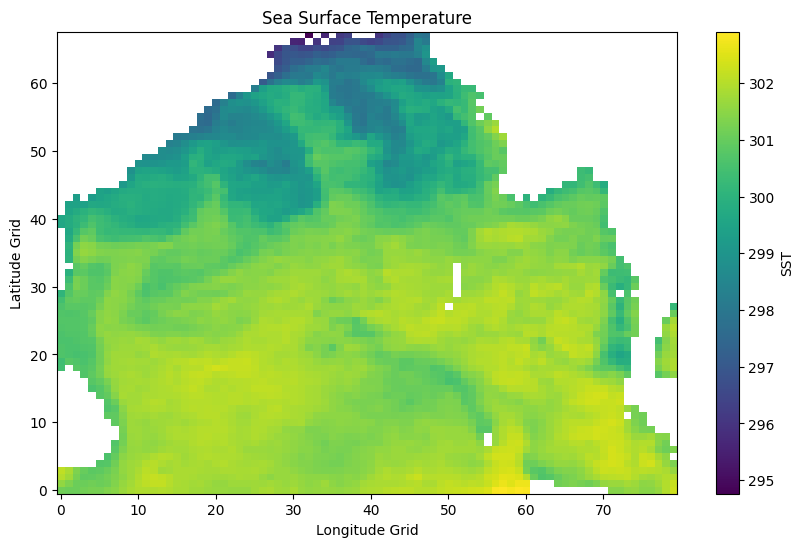

In [ ]:
# SST
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.imshow(
    X_sample[:, :, 0],
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="SST")
plt.title("Sea Surface Temperature")
plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")
plt.show()

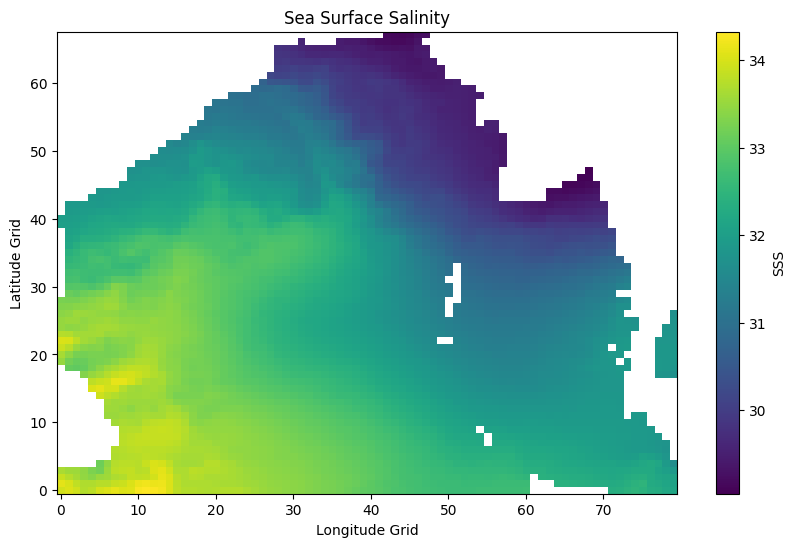

In [ ]:
# SSS
plt.figure(figsize=(10, 6))

plt.imshow(
    X_sample[:, :, 1],
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="SSS")
plt.title("Sea Surface Salinity")
plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")
plt.show()

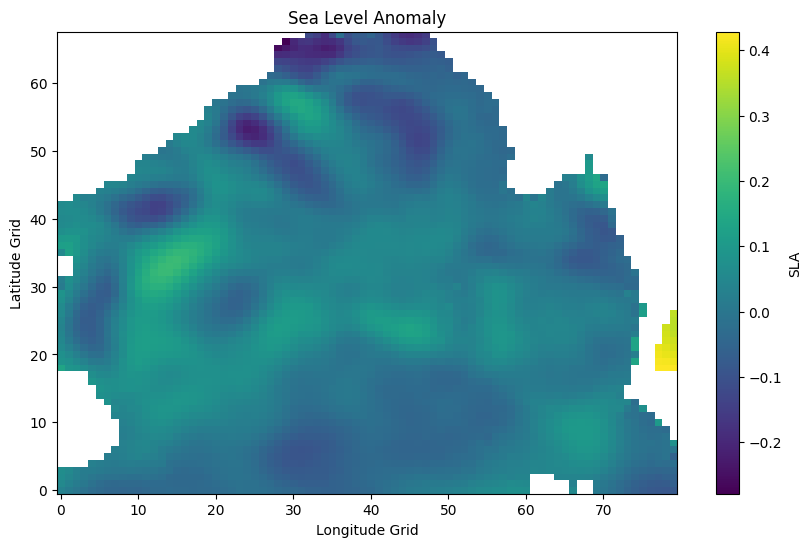

In [ ]:
# SLA
plt.figure(figsize=(10, 6))

plt.imshow(
    X_sample[:, :, 2],
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="SLA")
plt.title("Sea Level Anomaly")
plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")
plt.show()

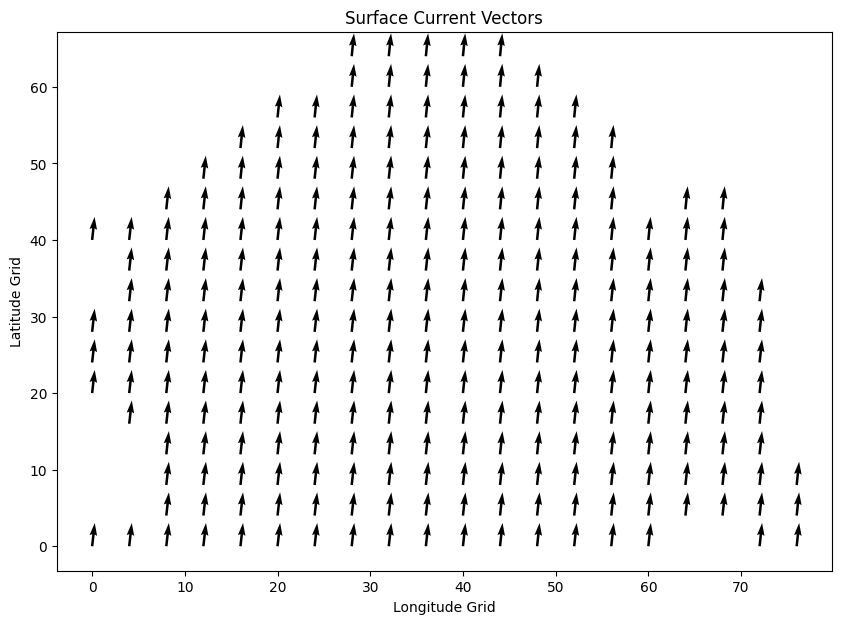

In [ ]:
# Current aur wind vectors
Y_grid, X_grid = np.meshgrid(
    np.arange(X_sample.shape[1]),
    np.arange(X_sample.shape[0])
)

plt.figure(figsize=(10, 7))

plt.quiver(
    Y_grid[::4, ::4],
    X_grid[::4, ::4],
    X_sample[::4, ::4, 1],
    X_sample[::4, ::4, 0]
)

plt.title("Surface Current Vectors")
plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")
plt.show()

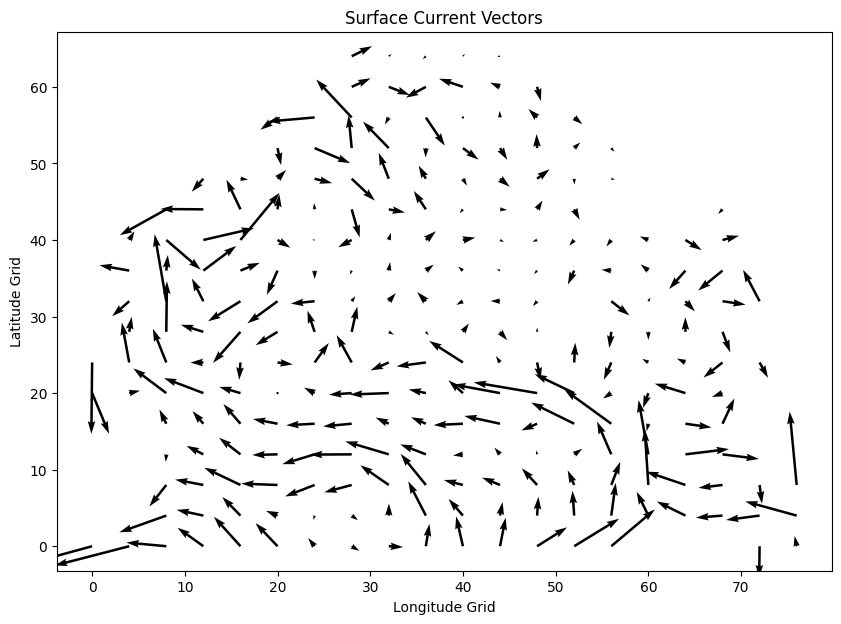

In [ ]:
#So correct current plot:
plt.figure(figsize=(10, 7))

plt.quiver(
    Y_grid[::4, ::4],
    X_grid[::4, ::4],
    X_sample[::4, ::4, 3],
    X_sample[::4, ::4, 4]
)

plt.title("Surface Current Vectors")
plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")
plt.show()

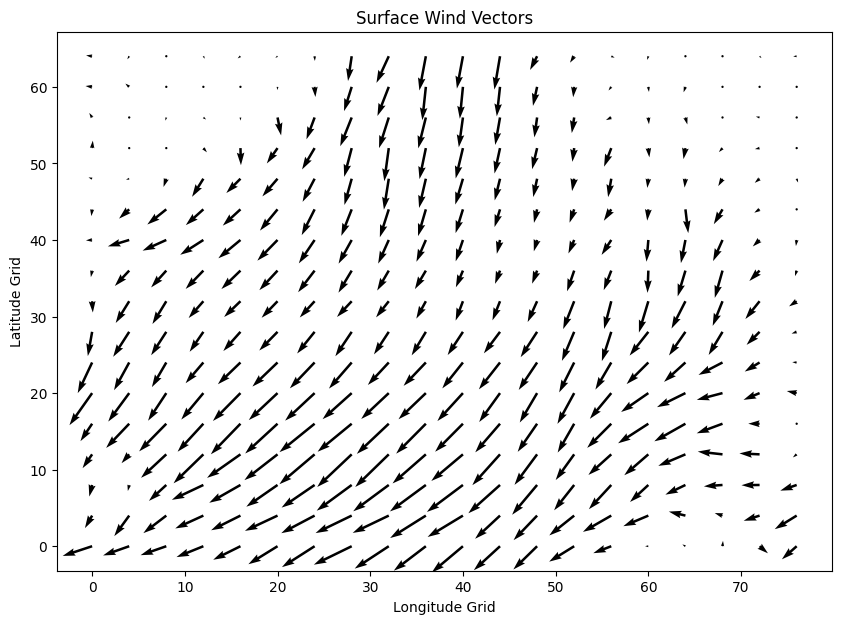

In [ ]:
# Wind
plt.figure(figsize=(10, 7))

plt.quiver(
    Y_grid[::4, ::4],
    X_grid[::4, ::4],
    X_sample[::4, ::4, 5],
    X_sample[::4, ::4, 6]
)

plt.title("Surface Wind Vectors")
plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")
plt.show()

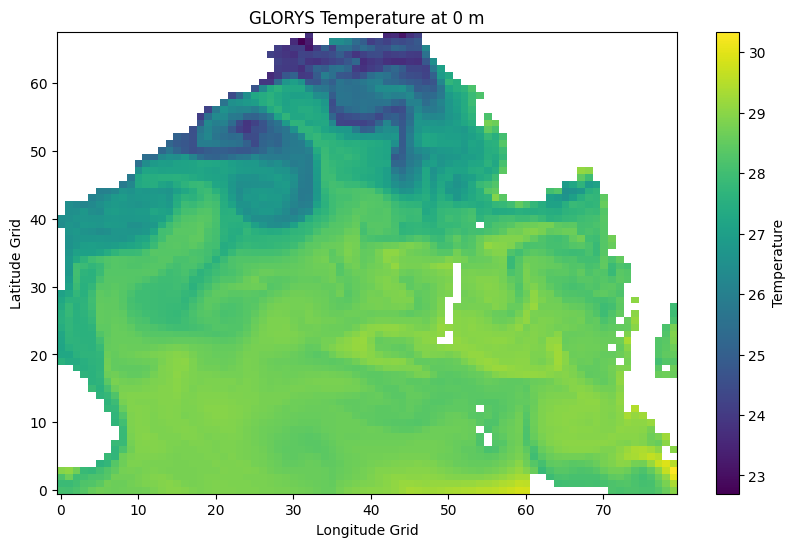

In [ ]:
# Target temperature visualization
# Surface temperature — 0m


depth_index = 0

plt.figure(figsize=(10, 6))

plt.imshow(
    Y_sample[:, :, depth_index],
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Temperature")
plt.title("GLORYS Temperature at 0 m")
plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")
plt.show()

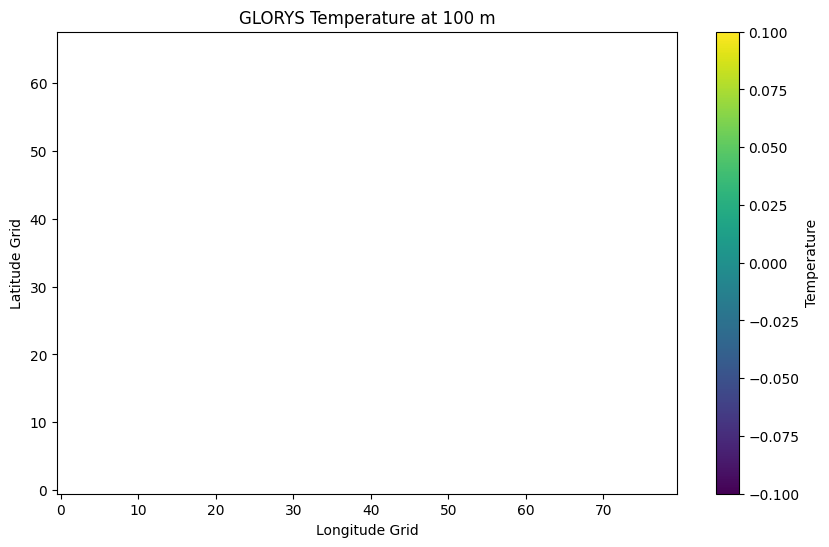

In [ ]:
# 100m
depth_index = TARGET_DEPTHS.index(100)

plt.figure(figsize=(10, 6))

plt.imshow(
    Y_sample[:, :, depth_index],
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Temperature")
plt.title("GLORYS Temperature at 100 m")
plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")
plt.show()

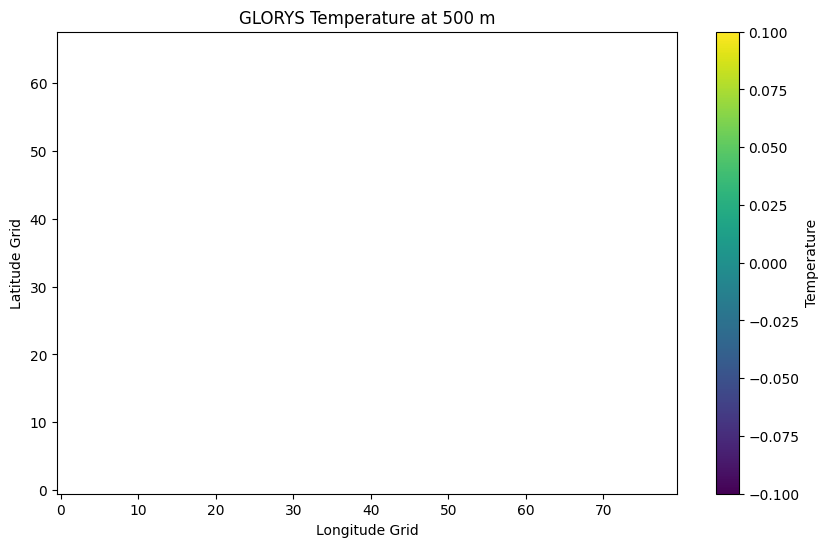

In [ ]:
# 500 m
depth_index = TARGET_DEPTHS.index(500)

plt.figure(figsize=(10, 6))

plt.imshow(
    Y_sample[:, :, depth_index],
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Temperature")
plt.title("GLORYS Temperature at 500 m")
plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")
plt.show()

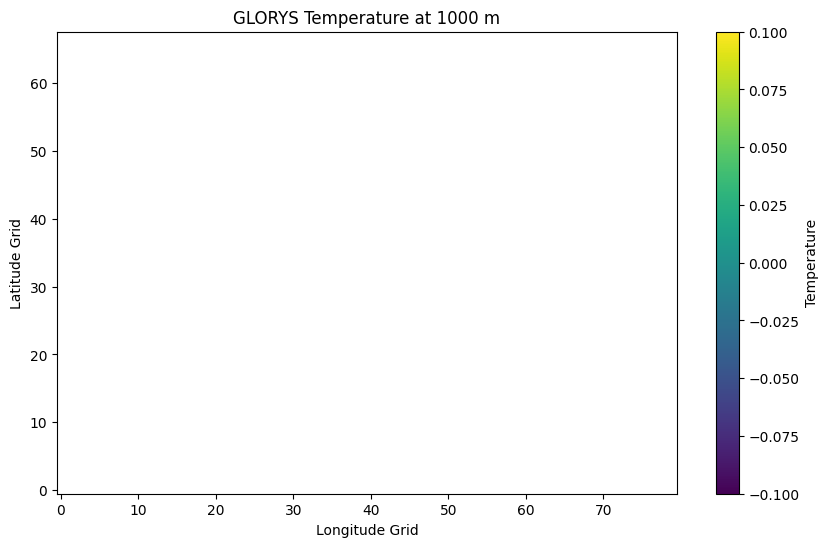

In [ ]:
# 1000m
depth_index = TARGET_DEPTHS.index(1000)

plt.figure(figsize=(10, 6))

plt.imshow(
    Y_sample[:, :, depth_index],
    origin="lower",
    aspect="auto"
)

plt.colorbar(label="Temperature")
plt.title("GLORYS Temperature at 1000 m")
plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")
plt.show()

In [ ]:
print("=" * 70)
print("VALID TEMPERATURE DATA BY DEPTH")
print("=" * 70)

for i, depth in enumerate(TARGET_DEPTHS):

    temp = Y_sample[:, :, i]

    valid = np.isfinite(temp)

    print(
        f"Depth {depth:4d} m | "
        f"Valid = {valid.sum():5d} | "
        f"NaN = {(~valid).sum():5d} | "
        f"Valid % = {valid.mean()*100:6.2f}%"
    )

VALID TEMPERATURE DATA BY DEPTH
Depth    0 m | Valid =  4003 | NaN =  1437 | Valid % =  73.58%
Depth    5 m | Valid =  4003 | NaN =  1437 | Valid % =  73.58%
Depth   10 m | Valid =  3891 | NaN =  1549 | Valid % =  71.53%
Depth   20 m | Valid =  3791 | NaN =  1649 | Valid % =  69.69%
Depth   30 m | Valid =  3715 | NaN =  1725 | Valid % =  68.29%
Depth   50 m | Valid =  3602 | NaN =  1838 | Valid % =  66.21%
Depth   75 m | Valid =  3450 | NaN =  1990 | Valid % =  63.42%
Depth  100 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth  125 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth  150 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth  200 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth  300 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth  500 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth  700 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth 1000 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%


In [ ]:
print("\n" + "=" * 70)
print("DEEP DEPTH CHECK")
print("=" * 70)

for depth in [0, 100, 500, 1000]:

    i = TARGET_DEPTHS.index(depth)
    temp = Y_sample[:, :, i]

    print(f"\nDepth: {depth} m")
    print("Valid cells :", np.isfinite(temp).sum())
    print("NaN cells   :", np.isnan(temp).sum())

    if np.isfinite(temp).any():
        print("Min         :", np.nanmin(temp))
        print("Max         :", np.nanmax(temp))
        print("Mean        :", np.nanmean(temp))


DEEP DEPTH CHECK

Depth: 0 m
Valid cells : 4003
NaN cells   : 1437
Min         : 22.69783
Max         : 30.338848
Mean        : 27.968317

Depth: 100 m
Valid cells : 0
NaN cells   : 5440

Depth: 500 m
Valid cells : 0
NaN cells   : 5440

Depth: 1000 m
Valid cells : 0
NaN cells   : 5440


In [ ]:
print("=" * 70)
print("THETAO VALID DATA BY DEPTH")
print("=" * 70)

for i, depth in enumerate(ds["depth"].values):

    temp = ds["thetao"].isel(time=0, depth=i).values

    valid = np.isfinite(temp)

    print(
        f"Depth {depth:7.1f} m | "
        f"Valid: {valid.sum():5d} | "
        f"NaN: {(~valid).sum():5d} | "
        f"Valid %: {valid.mean()*100:6.2f}%"
    )

THETAO VALID DATA BY DEPTH
Depth     0.0 m | Valid:  4003 | NaN:  1437 | Valid %:  73.58%
Depth     5.0 m | Valid:  4003 | NaN:  1437 | Valid %:  73.58%
Depth    10.0 m | Valid:  3891 | NaN:  1549 | Valid %:  71.53%
Depth    20.0 m | Valid:  3791 | NaN:  1649 | Valid %:  69.69%
Depth    30.0 m | Valid:  3715 | NaN:  1725 | Valid %:  68.29%
Depth    50.0 m | Valid:  3602 | NaN:  1838 | Valid %:  66.21%
Depth    75.0 m | Valid:  3450 | NaN:  1990 | Valid %:  63.42%
Depth   100.0 m | Valid:     0 | NaN:  5440 | Valid %:   0.00%
Depth   125.0 m | Valid:     0 | NaN:  5440 | Valid %:   0.00%
Depth   150.0 m | Valid:     0 | NaN:  5440 | Valid %:   0.00%
Depth   200.0 m | Valid:     0 | NaN:  5440 | Valid %:   0.00%
Depth   300.0 m | Valid:     0 | NaN:  5440 | Valid %:   0.00%
Depth   500.0 m | Valid:     0 | NaN:  5440 | Valid %:   0.00%
Depth   700.0 m | Valid:     0 | NaN:  5440 | Valid %:   0.00%
Depth  1000.0 m | Valid:     0 | NaN:  5440 | Valid %:   0.00%


In [ ]:
print("=" * 70)
print("THETAO DEPTH COORDINATE")
print("=" * 70)

print(ds["thetao"])
print("\nDepth values:")
print(ds["depth"].values)

THETAO DEPTH COORDINATE
<xarray.DataArray 'thetao' (time: 1, depth: 15, y: 68, x: 80)> Size: 653kB
array([[[[28.086218, ..., 28.979247],
         ...,
         [      nan, ...,       nan]],

        ...,

        [[      nan, ...,       nan],
         ...,
         [      nan, ...,       nan]]]])
Coordinates:
  * time     (time) datetime64[ns] 8B 2024-01-01
  * depth    (depth) float32 60B 0.0 5.0 10.0 20.0 ... 300.0 500.0 700.0 1e+03
    lon      (y, x) float64 44kB ...
    lat      (y, x) float64 44kB ...
Dimensions without coordinates: y, x

Depth values:
[   0.    5.   10.   20.   30.   50.   75.  100.  125.  150.  200.  300.
  500.  700. 1000.]


In [ ]:
print("\nThetao attributes:")
print(ds["thetao"].attrs)


Thetao attributes:
{}


In [ ]:
print("=" * 70)
print("VALID TEMPERATURE DATA BY DEPTH")
print("=" * 70)

for i, depth in enumerate(ds["depth"].values):

    temp = ds["thetao"].isel(time=0, depth=i).values
    valid = np.isfinite(temp)

    print(
        f"Depth {depth:7.1f} m | "
        f"Valid = {valid.sum():5d} | "
        f"NaN = {(~valid).sum():5d} | "
        f"Valid % = {valid.mean()*100:6.2f}%"
    )

VALID TEMPERATURE DATA BY DEPTH
Depth     0.0 m | Valid =  4003 | NaN =  1437 | Valid % =  73.58%
Depth     5.0 m | Valid =  4003 | NaN =  1437 | Valid % =  73.58%
Depth    10.0 m | Valid =  3891 | NaN =  1549 | Valid % =  71.53%
Depth    20.0 m | Valid =  3791 | NaN =  1649 | Valid % =  69.69%
Depth    30.0 m | Valid =  3715 | NaN =  1725 | Valid % =  68.29%
Depth    50.0 m | Valid =  3602 | NaN =  1838 | Valid % =  66.21%
Depth    75.0 m | Valid =  3450 | NaN =  1990 | Valid % =  63.42%
Depth   100.0 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth   125.0 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth   150.0 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth   200.0 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth   300.0 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth   500.0 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth   700.0 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth  1000.0 m | Valid =     0 | NaN =  544

In [ ]:
print("=" * 70)
print("CHECK ALL THETAO DEPTHS IN ORIGINAL/PREPROCESSED SOURCE")
print("=" * 70)

print("thetao dimensions:")
print(ds["thetao"].dims)

print("\nthetao shape:")
print(ds["thetao"].shape)

print("\ndepth coordinate:")
print(ds["depth"].values)

print("\nValid cells by depth:")
for i, depth in enumerate(ds["depth"].values):
    temp = ds["thetao"].isel(time=0, depth=i).values

    valid = np.isfinite(temp)

    print(
        f"Depth {depth:7.1f} m | "
        f"Valid = {valid.sum():5d} | "
        f"NaN = {(~valid).sum():5d} | "
        f"Valid % = {valid.mean()*100:6.2f}%"
    )

CHECK ALL THETAO DEPTHS IN ORIGINAL/PREPROCESSED SOURCE
thetao dimensions:
('time', 'depth', 'y', 'x')

thetao shape:
(1, 15, 68, 80)

depth coordinate:
[   0.    5.   10.   20.   30.   50.   75.  100.  125.  150.  200.  300.
  500.  700. 1000.]

Valid cells by depth:
Depth     0.0 m | Valid =  4003 | NaN =  1437 | Valid % =  73.58%
Depth     5.0 m | Valid =  4003 | NaN =  1437 | Valid % =  73.58%
Depth    10.0 m | Valid =  3891 | NaN =  1549 | Valid % =  71.53%
Depth    20.0 m | Valid =  3791 | NaN =  1649 | Valid % =  69.69%
Depth    30.0 m | Valid =  3715 | NaN =  1725 | Valid % =  68.29%
Depth    50.0 m | Valid =  3602 | NaN =  1838 | Valid % =  66.21%
Depth    75.0 m | Valid =  3450 | NaN =  1990 | Valid % =  63.42%
Depth   100.0 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth   125.0 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth   150.0 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth   200.0 m | Valid =     0 | NaN =  5440 | Valid % =   0.00%
Depth

In [ ]:
from pathlib import Path

print("=" * 70)
print("SEARCHING FOR GLORYS FILES")
print("=" * 70)

for p in Path("/content/drive/MyDrive").rglob("*.nc"):
    name = p.name.lower()

    if "glorys" in name or "thetao" in name or "phy" in name:
        print(p)

SEARCHING FOR GLORYS FILES


In [ ]:
print("=" * 70)
print("SEARCHING NOTEBOOK FOR THETAO / GLORYS PROCESSING")
print("=" * 70)

# Read the notebook source if the notebook path exists
from pathlib import Path
import json

notebook_candidates = list(Path("/content/drive/MyDrive").rglob("*.ipynb"))

print("Notebooks found:", len(notebook_candidates))

for p in notebook_candidates:
    if "sih" in p.name.lower() or "ocean" in p.name.lower() or "glory" in p.name.lower():
        print(p)

SEARCHING NOTEBOOK FOR THETAO / GLORYS PROCESSING
Notebooks found: 10
/content/drive/MyDrive/Colab Notebooks/sih shit tryout.ipynb
/content/drive/MyDrive/Colab Notebooks/data sih.ipynb
/content/drive/MyDrive/Colab Notebooks/SIH_1.ipynb
/content/drive/MyDrive/Colab Notebooks/SIH2026 PS66.ipynb
/content/drive/MyDrive/Colab Notebooks/SIH2026_PS66_automated_colab_monthwise.ipynb


In [ ]:
NOTEBOOK_PATH = "/content/drive/MyDrive/YOUR_NOTEBOOK.ipynb"

with open(NOTEBOOK_PATH, "r", encoding="utf-8") as f:
    nb = json.load(f)

print("=" * 70)
print("CELLS CONTAINING GLORYS / THETAO / DEPTH")
print("=" * 70)

keywords = [
    "thetao",
    "glorys",
    "depth",
    "temperature",
    "reindex",
    "interp",
    "surface"
]

for i, cell in enumerate(nb["cells"]):

    source = "".join(cell.get("source", []))

    if any(k.lower() in source.lower() for k in keywords):

        print("\n" + "=" * 70)
        print(f"CELL {i}")
        print("=" * 70)
        print(source[:5000])

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/YOUR_NOTEBOOK.ipynb'

In [ ]:
from pathlib import Path

print("=" * 70)
print("SEARCHING FOR NOTEBOOKS")
print("=" * 70)

notebooks = list(Path("/content/drive/MyDrive").rglob("*.ipynb"))

print("Total notebooks found:", len(notebooks))
print()

for i, p in enumerate(notebooks):
    print(f"[{i}] {p}")

SEARCHING FOR NOTEBOOKS
Total notebooks found: 10

[0] /content/drive/MyDrive/Colab Notebooks/sih shit tryout.ipynb
[1] /content/drive/MyDrive/Colab Notebooks/BGMI1.ipynb
[2] /content/drive/MyDrive/Colab Notebooks/Daa-assignment.ipynb
[3] /content/drive/MyDrive/Colab Notebooks/Black-box-01.ipynb
[4] /content/drive/MyDrive/Colab Notebooks/surface wind level 4.ipynb
[5] /content/drive/MyDrive/Colab Notebooks/data sih.ipynb
[6] /content/drive/MyDrive/Colab Notebooks/SIH_1.ipynb
[7] /content/drive/MyDrive/Colab Notebooks/SIH2026 PS66.ipynb
[8] /content/drive/MyDrive/Colab Notebooks/paras updated.ipynb
[9] /content/drive/MyDrive/Colab Notebooks/SIH2026_PS66_automated_colab_monthwise.ipynb


In [ ]:
from pathlib import Path

print("=" * 80)
print("SEARCHING FOR RAW GLORYS / TEMPERATURE FILES")
print("=" * 80)

roots = [
    Path("/content/OceanEmbed"),
    Path("/content/drive/MyDrive")
]

found = []

for root in roots:
    if root.exists():
        for p in root.rglob("*.nc"):
            path_lower = str(p).lower()

            if (
                "temperature" in path_lower
                or "glorys" in path_lower
                or "cmems_mod_glo_phy" in path_lower
            ):
                found.append(p)

print("\nFiles found:", len(found))

for p in found[:30]:
    print(p)

SEARCHING FOR RAW GLORYS / TEMPERATURE FILES

Files found: 0
